In [2]:
import tensorflow as tf

(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

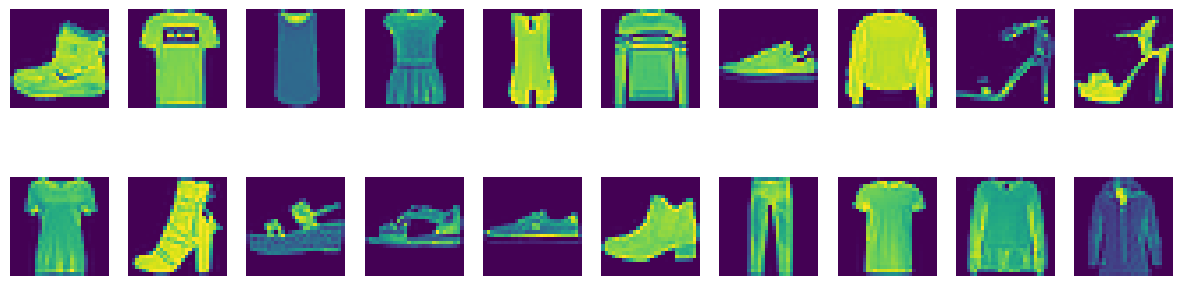

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
for i in range(20):
    plt.subplot(2, 10, (i+1))
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()

In [5]:
# 28*28 이미지 0~255사이의 숫자로 minmax 0~1
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [ ]:
# 스케일 minmax 0~1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [8]:
# (n, 28, 28) => (n, 784)
x_train1 = x_train.reshape(-1, 28*28)
x_test1 = x_test.reshape(-1, 28*28)

x_train1.shape, x_test1.shape

((60000, 784), (10000, 784))

In [10]:
# 비지도 학습 x만 존재함
from sklearn.cluster import KMeans

model = KMeans(n_clusters=10, random_state=123)
model.fit(x_train1)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


In [11]:
model.labels_

array([7, 0, 5, ..., 0, 5, 5], shape=(60000,), dtype=int32)

In [14]:
# 10000개의 테스트 데이터를 예측
pred = model.predict(x_test1)
pred

array([3, 4, 6, ..., 2, 6, 5], shape=(10000,), dtype=int32)

In [42]:
# 0~9사이의 숫자로 분류한 것 중에 0에 해당하는 것만 pred_0에 보관
import numpy as np
pred_0 = np.where(pred==3)[0]
# pred_0

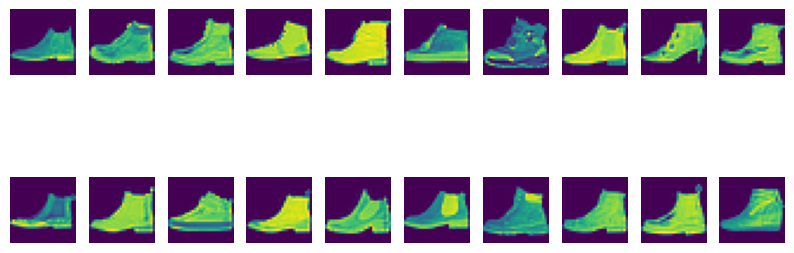

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(20):
    plt.subplot(2, 10, (i+1))
    plt.imshow(x_test[pred_0[i]])
    plt.axis('off')

plt.show()